# All-Blue Edge Interaction Experiment

Start from the maximally violating all-blue K43 coloring and introduce exactly `n` red edges with several geometries. The experiment asks how the geometry of those flips changes the *interaction landscape* between future edge actions.

For an oriented pair `(e1, e2)`, define the reward interaction

`J(e1,e2) = reward(e2 after e1) - reward(e2 before e1)`.

`J = 0` means the two actions are additive at the Ramsey-score level. Positive values mean `e1` makes `e2` a better immediate action; negative values mean it makes `e2` worse. This is a mixed finite difference, not a distance heuristic.

The experiment deliberately uses no tabu memory and no learned model. It measures the coloring itself.

This pairwise interaction is also the first reusable measurement for a future action model in which one action is a *set* of coordinated edge flips rather than a single edge.

In [1]:
from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey.RAction import analyze_actions
from ramsey.RColoring import RColoring
from ramsey.REdgeFlipability import calculate_edge_flipability
from ramsey.REdgeInteraction import calculate_edge_pair_interactions
from ramsey.RFlexibility import calculate_flexibility
from ramsey.RGraph import RGraph
from ramsey.RProblem import RProblem
from ramsey.RState import RSearchState

RANDOM_SEED = 202_608_074
N_VERTICES = 43
CHECKPOINTS = (0, 1, 2, 4, 8, 16, 21)
FLEXIBILITY_BUDGETS = (0, 1, 2, 5)
INTERACTION_PAIRS_PER_CLASS = 128
STOCHASTIC_REPLICATES = 4

graph_start = perf_counter()
graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
graph_elapsed = perf_counter() - graph_start
rng = np.random.default_rng(RANDOM_SEED)

print('Vertices:', graph.problem.n_vertices)
print('Edges:', graph.number_of_edges)
print('K5s:', graph.subgraph_index(5).clique_count)
print('Checkpoints:', CHECKPOINTS)
print('Interaction pairs per geometry:', INTERACTION_PAIRS_PER_CLASS)
print('Stochastic replicates:', STOCHASTIC_REPLICATES)
print('Graph setup:', f'{graph_elapsed:.3f}s')

Vertices: 43
Edges: 903
K5s: 962598
Checkpoints: (0, 1, 2, 4, 8, 16, 21)
Interaction pairs per geometry: 128
Stochastic replicates: 4
Graph setup: 1.494s


In [2]:
# Build one fixed, stratified interaction sample. Every state is
# evaluated on exactly the same adjacent/disjoint edge pairs.
all_pairs = np.asarray(
    list(combinations(range(graph.number_of_edges), 2)),
    dtype=np.int32,
)
pair_endpoints = graph.edges[all_pairs]
adjacent_mask = (
    (pair_endpoints[:, 0, 0, None] == pair_endpoints[:, 1]).any(axis=1)
    | (pair_endpoints[:, 0, 1, None] == pair_endpoints[:, 1]).any(axis=1)
)
adjacent_pairs = all_pairs[adjacent_mask]
disjoint_pairs = all_pairs[~adjacent_mask]

interaction_pairs = np.vstack([
    adjacent_pairs[rng.choice(
        len(adjacent_pairs), INTERACTION_PAIRS_PER_CLASS, replace=False
    )],
    disjoint_pairs[rng.choice(
        len(disjoint_pairs), INTERACTION_PAIRS_PER_CLASS, replace=False
    )],
]).astype(np.int32)

print('Adjacent host-edge pairs:', f'{len(adjacent_pairs):,}')
print('Disjoint host-edge pairs:', f'{len(disjoint_pairs):,}')
print('Pairs measured per state:', len(interaction_pairs))

Adjacent host-edge pairs: 37,023
Disjoint host-edge pairs: 370,230
Pairs measured per state: 256


In [3]:
edge_lookup = {
    (int(i), int(j)): edge
    for edge, (i, j) in enumerate(graph.edges)
}

def edge_index(i, j):
    return edge_lookup[tuple(sorted((int(i), int(j))))]


def path_edges(n):
    if n > N_VERTICES - 1:
        raise ValueError('A simple path can contain at most 42 edges.')
    return np.asarray([edge_index(i, i + 1) for i in range(n)], dtype=np.int32)


def matching_edges(n):
    if n > N_VERTICES // 2:
        raise ValueError('A K43 matching can contain at most 21 edges.')
    return np.asarray([edge_index(2 * i, 2 * i + 1) for i in range(n)], dtype=np.int32)


def star_edges(n):
    if n > N_VERTICES - 1:
        raise ValueError('A K43 star can contain at most 42 edges.')
    return np.asarray([edge_index(0, i + 1) for i in range(n)], dtype=np.int32)


def cycle_edges(n):
    if n == 0:
        return np.empty(0, dtype=np.int32)
    if n < 3 or n > N_VERTICES:
        raise ValueError('A simple cycle requires 3 through 43 edges.')
    vertices = list(range(n))
    return np.asarray(
        [edge_index(vertices[i], vertices[(i + 1) % n]) for i in range(n)],
        dtype=np.int32,
    )


def random_prefix_sets(local_rng):
    ordering = local_rng.permutation(graph.number_of_edges).astype(np.int32)
    return {n: ordering[:n].copy() for n in CHECKPOINTS}


def greedy_additive_prefix_sets(local_rng):
    state = RSearchState(RColoring(
        graph, np.ones(graph.number_of_edges, dtype=np.uint8)
    ))
    selected = []
    result = {0: np.empty(0, dtype=np.int32)}
    checkpoint_set = set(CHECKPOINTS)

    for step in range(1, max(CHECKPOINTS) + 1):
        rewards = analyze_actions(state).immediate_rewards
        unflipped = state.colors == 1
        best_reward = rewards[unflipped].max()
        candidates = np.flatnonzero(unflipped & (rewards == best_reward))
        edge = int(local_rng.choice(candidates))
        state.apply_edge_flip(edge)
        selected.append(edge)

        if step in checkpoint_set:
            result[step] = np.asarray(selected, dtype=np.int32)

    return result

In [4]:
# Create the exact edge sets to compare. Deterministic geometries
# need only one representative because the all-blue state is
# invariant under vertex renaming. Random and greedy-additive
# constructions get independent replicates.
experiments = []

for strategy, builder in (
    ('matching', matching_edges),
    ('path', path_edges),
    ('star', star_edges),
):
    for n in CHECKPOINTS:
        experiments.append((strategy, 0, n, builder(n)))

for n in CHECKPOINTS:
    if n == 0 or n >= 3:
        experiments.append(('cycle', 0, n, cycle_edges(n)))

for replicate in range(STOCHASTIC_REPLICATES):
    random_sets = random_prefix_sets(np.random.default_rng(
        RANDOM_SEED + 1_000 + replicate
    ))
    greedy_sets = greedy_additive_prefix_sets(np.random.default_rng(
        RANDOM_SEED + 2_000 + replicate
    ))

    for n in CHECKPOINTS:
        experiments.append(('random', replicate, n, random_sets[n]))
        experiments.append(('greedy-additive', replicate, n, greedy_sets[n]))

print('State measurements scheduled:', len(experiments))

State measurements scheduled: 82


In [5]:
def state_from_red_edges(red_edges):
    colors = np.ones(graph.number_of_edges, dtype=np.uint8)
    colors[np.asarray(red_edges, dtype=np.int32)] = 0
    return RSearchState(RColoring(graph, colors))


def red_vertex_degrees(state):
    red_endpoints = graph.edges[state.colors == 0].reshape(-1)
    return np.bincount(red_endpoints, minlength=N_VERTICES)


def measure_state(strategy, replicate, n, red_edges):
    state = state_from_red_edges(red_edges)
    analysis = analyze_actions(state)
    rewards = analysis.immediate_rewards.astype(np.float64)
    flexibility = calculate_flexibility(
        analysis.immediate_rewards, FLEXIBILITY_BUDGETS
    )
    roles = calculate_edge_flipability(state, analysis).role_profiles
    role_fractions = roles.sum(axis=0, dtype=np.float64) / roles.sum()
    interaction = calculate_edge_pair_interactions(state, interaction_pairs)
    degrees = red_vertex_degrees(state).astype(np.float64)

    row = {
        'strategy': strategy,
        'replicate': replicate,
        'n': n,
        'score': state.score,
        'red_violations': int(state.histogram[0]),
        'blue_violations': int(state.histogram[-1]),
        'red_degree_std': float(degrees.std()),
        'red_degree_max': int(degrees.max()),
        'reward_mean': float(rewards.mean()),
        'reward_std': float(rewards.std()),
        'reward_best': int(rewards.max()),
        'reward_worst': int(rewards.min()),
        'improving_actions': int(np.count_nonzero(rewards > 0)),
        'neutral_actions': int(np.count_nonzero(rewards == 0)),
        **interaction.summary(),
    }

    for budget in FLEXIBILITY_BUDGETS:
        row[f'F{budget}'] = flexibility.fraction_at(budget)

    for bin_index, count in enumerate(state.histogram):
        row[f'H{bin_index}'] = int(count)

    for role_index, fraction in enumerate(role_fractions, start=1):
        row[f'N{role_index}_fraction'] = float(fraction)

    return row


rows = []
experiment_start = perf_counter()

for index, (strategy, replicate, n, red_edges) in enumerate(experiments, start=1):
    row = measure_state(strategy, replicate, n, red_edges)
    rows.append(row)

    if index == 1 or index % 10 == 0 or index == len(experiments):
        print(
            f'{index:3d}/{len(experiments):3d} | '
            f'{strategy:15s} | rep={replicate} | n={n:2d} | '
            f'score={row["score"]:6d} | F5={row["F5"]:7.3%} | '
            f'|J|={row["interaction_mean_abs"]:7.2f}'
        )

results = pd.DataFrame(rows)
experiment_elapsed = perf_counter() - experiment_start

baseline = results[results['n'] == 0].iloc[0]
assert baseline['score'] == graph.subgraph_index(5).clique_count
assert np.isclose(baseline['adjacent_interaction_mean'], -780.0)
assert np.isclose(baseline['disjoint_interaction_mean'], -39.0)

print()
print('Elapsed:', f'{experiment_elapsed:.2f}s')
print('Rows:', len(results))
print('All-blue analytical interaction check: PASS')

  1/ 82 | matching        | rep=0 | n= 0 | score=962598 | F5=100.000% | |J|= 409.50
 10/ 82 | path            | rep=0 | n= 2 | score=942058 | F5=99.779% | |J|= 403.37
 20/ 82 | star            | rep=0 | n=16 | score=865618 | F5=98.228% | |J|= 372.12
 30/ 82 | greedy-additive | rep=0 | n= 1 | score=951938 | F5=99.889% | |J|= 405.93
 40/ 82 | greedy-additive | rep=0 | n=21 | score=746928 | F5=97.674% | |J|= 339.82
 50/ 82 | greedy-additive | rep=1 | n= 8 | score=878410 | F5=99.114% | |J|= 374.93
 60/ 82 | greedy-additive | rep=2 | n= 2 | score=941317 | F5=99.779% | |J|= 400.43
 70/ 82 | greedy-additive | rep=3 | n= 0 | score=962598 | F5=100.000% | |J|= 409.50
 80/ 82 | greedy-additive | rep=3 | n=16 | score=796718 | F5=98.228% | |J|= 352.99
 82/ 82 | greedy-additive | rep=3 | n=21 | score=746928 | F5=97.674% | |J|= 338.87

Elapsed: 26.47s
Rows: 82
All-blue analytical interaction check: PASS


In [6]:
# Strategy means. Deterministic geometries have one representative;
# stochastic strategies are averaged over their replicates.
summary = (
    results.groupby(['strategy', 'n'], as_index=False)
    .agg(
        score=('score', 'mean'),
        F0=('F0', 'mean'),
        F5=('F5', 'mean'),
        reward_best=('reward_best', 'mean'),
        reward_std=('reward_std', 'mean'),
        interaction_abs=('interaction_mean_abs', 'mean'),
        adjacent_J=('adjacent_interaction_mean', 'mean'),
        disjoint_J=('disjoint_interaction_mean', 'mean'),
        red_degree_std=('red_degree_std', 'mean'),
        N1=('N1_fraction', 'mean'),
        N2=('N2_fraction', 'mean'),
        N9=('N9_fraction', 'mean'),
        N10=('N10_fraction', 'mean'),
    )
)

summary

,strategy,n,score,F0,F5,reward_best,reward_std,interaction_abs,adjacent_J,disjoint_J,red_degree_std,N1,N2,N9,N10
0,cycle,0,962598.00,1.000000,1.000000,10660.00,0.000000,409.500000,-780.000000,-39.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,cycle,4,923039.00,0.995570,0.995570,10508.00,1389.660655,395.859375,-753.757812,-37.960938,0.580930,0.003798,0.000616,0.034179,0.958904
2,cycle,8,884002.00,0.991141,0.991141,10356.00,1900.655294,378.125000,-708.953125,-34.062500,0.778288,0.007505,0.001254,0.067542,0.918350
3,cycle,16,807774.00,0.982281,0.982281,10052.00,2498.426439,352.191406,-617.085938,-29.843750,0.966726,0.014531,0.002947,0.130776,0.839160
4,cycle,21,761334.00,0.976744,0.976744,9862.00,2727.531356,333.281250,-559.726562,-27.695312,0.999730,0.018679,0.004228,0.168109,0.790916
5,greedy-additive,0,962598.00,1.000000,1.000000,10660.00,0.000000,409.500000,-780.000000,-39.000000,0.000000,0.000000,0.000000,0.000000,1.000000
6,greedy-additive,1,951938.00,0.998893,0.998893,10621.00,736.977381,405.452148,-766.267578,-38.390625,0.210590,0.001107,0.000000,0.009967,0.988926
7,greedy-additive,2,941317.00,0.997785,0.997785,10582.00,1032.818316,401.410156,-749.296875,-38.156250,0.290465,0.002207,0.000008,0.019861,0.977892
8,greedy-additive,4,920192.00,0.995570,0.995570,10504.00,1433.992132,394.515625,-733.134766,-36.931641,0.389144,0.004381,0.000049,0.039430,0.955946
9,greedy-additive,8,878410.00,0.991141,0.991141,10348.00,1952.767351,380.407227,-686.158203,-34.941406,0.483363,0.008632,0.000227,0.077692,0.912541


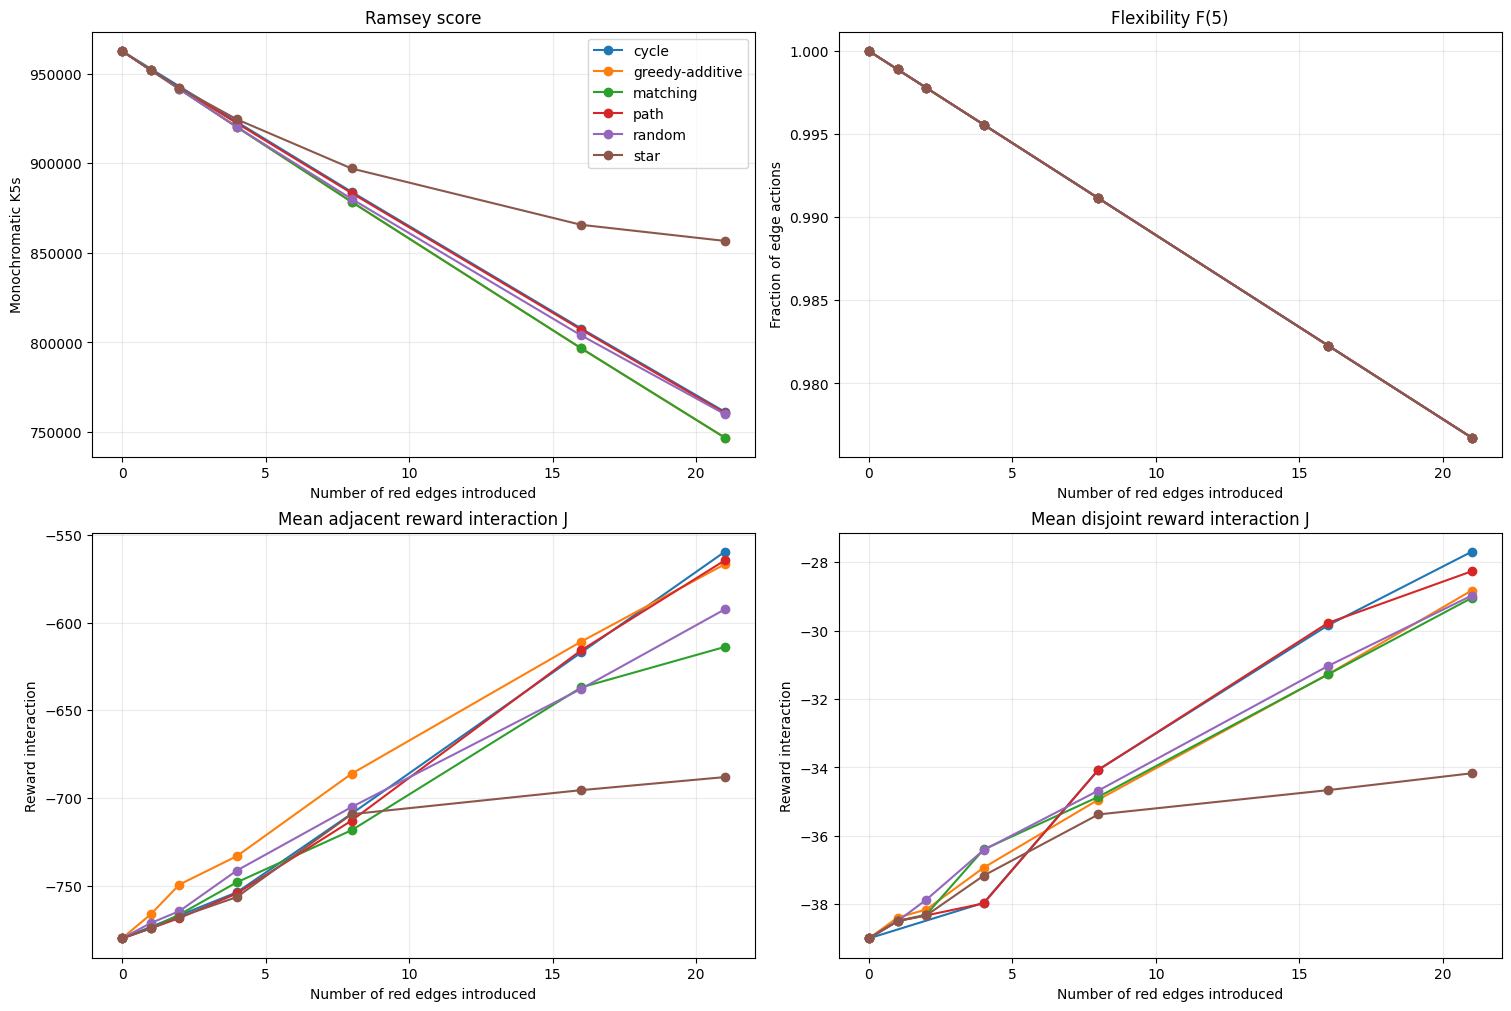

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

for strategy, frame in summary.groupby('strategy'):
    axes[0, 0].plot(frame['n'], frame['score'], marker='o', label=strategy)
    axes[0, 1].plot(frame['n'], frame['F5'], marker='o', label=strategy)
    axes[1, 0].plot(frame['n'], frame['adjacent_J'], marker='o', label=strategy)
    axes[1, 1].plot(frame['n'], frame['disjoint_J'], marker='o', label=strategy)

axes[0, 0].set_title('Ramsey score')
axes[0, 1].set_title('Flexibility F(5)')
axes[1, 0].set_title('Mean adjacent reward interaction J')
axes[1, 1].set_title('Mean disjoint reward interaction J')

for ax in axes.flat:
    ax.set_xlabel('Number of red edges introduced')
    ax.grid(alpha=0.25)

axes[0, 0].set_ylabel('Monochromatic K5s')
axes[0, 1].set_ylabel('Fraction of edge actions')
axes[1, 0].set_ylabel('Reward interaction')
axes[1, 1].set_ylabel('Reward interaction')
axes[0, 0].legend()
plt.show()

In [8]:
# COPY/PASTE REPORT
print('# ALL-BLUE EDGE INTERACTION REPORT')
print()
print(f'Checkpoints: {CHECKPOINTS}')
print(f'Stochastic replicates: {STOCHASTIC_REPLICATES}')
print(f'Interaction sample: {len(interaction_pairs)} pairs/state')
print(f'Elapsed: {experiment_elapsed:.2f}s')
print()
print(
    'strategy         n     score      F0      F5   bestR   sd(R)  '
    '|J|    J-adj    J-disj   degSD      N1      N2      N9     N10'
)
print('-' * 125)

for _, row in summary.sort_values(['n', 'strategy']).iterrows():
    print(
        f'{row["strategy"]:15s} {int(row["n"]):2d} '
        f'{row["score"]:9.1f} '
        f'{row["F0"]:7.3%} {row["F5"]:7.3%} '
        f'{row["reward_best"]:7.1f} {row["reward_std"]:7.1f} '
        f'{row["interaction_abs"]:6.1f} '
        f'{row["adjacent_J"]:8.1f} {row["disjoint_J"]:9.1f} '
        f'{row["red_degree_std"]:7.2f} '
        f'{row["N1"]:7.3%} {row["N2"]:7.3%} '
        f'{row["N9"]:7.3%} {row["N10"]:7.3%}'
    )

print()
print('FINAL-CHECKPOINT K5 HISTOGRAMS')
final_n = max(CHECKPOINTS)
for strategy, frame in results[results['n'] == final_n].groupby('strategy'):
    mean_histogram = frame[[f'H{i}' for i in range(11)]].mean().to_numpy()
    histogram_text = ', '.join(
        f'H{i}={value:.1f}' for i, value in enumerate(mean_histogram)
    )
    print(f'{strategy:15s} | {histogram_text}')

print()
print('Sign convention: J > 0 means e1 makes e2 a better score action.')
print('All-blue expectation: adjacent J=-780, disjoint J=-39.')

# ALL-BLUE EDGE INTERACTION REPORT

Checkpoints: (0, 1, 2, 4, 8, 16, 21)
Stochastic replicates: 4
Interaction sample: 256 pairs/state
Elapsed: 26.47s

strategy         n     score      F0      F5   bestR   sd(R)  |J|    J-adj    J-disj   degSD      N1      N2      N9     N10
-----------------------------------------------------------------------------------------------------------------------------
cycle            0  962598.0 100.000% 100.000% 10660.0     0.0  409.5   -780.0     -39.0    0.00  0.000%  0.000%  0.000% 100.000%
greedy-additive  0  962598.0 100.000% 100.000% 10660.0     0.0  409.5   -780.0     -39.0    0.00  0.000%  0.000%  0.000% 100.000%
matching         0  962598.0 100.000% 100.000% 10660.0     0.0  409.5   -780.0     -39.0    0.00  0.000%  0.000%  0.000% 100.000%
path             0  962598.0 100.000% 100.000% 10660.0     0.0  409.5   -780.0     -39.0    0.00  0.000%  0.000%  0.000% 100.000%
random           0  962598.0 100.000% 100.000% 10660.0     0.0  409.5   -780.0